In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import PIL.Image as Image
import torch.utils.data as data
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from ipywidgets import interact, fixed

PREFIX = '/kaggle/input/vesuvius-challenge/train/1/'
BUFFER = 30  # Buffer size in x and y direction
Z_START = 27 # First slice in the z direction to use
Z_DIM = 10   # Number of slices in the z direction
TRAINING_STEPS = 20000
LEARNING_RATE = 0.05
BATCH_SIZE = 24
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.imshow(Image.open(PREFIX+"ir.png"), cmap="gray")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/vesuvius-challenge/train/1/ir.png'

In [2]:
mask = np.array(Image.open(PREFIX+"mask.png").convert('1'))
label = torch.from_numpy(np.array(Image.open(PREFIX+"inklabels.png"))).gt(0).float().to(DEVICE)
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.set_title("mask.png")
ax1.imshow(mask, cmap='gray')
ax2.set_title("inklabels.png")
ax2.imshow(label.cpu(), cmap='gray')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/vesuvius-challenge/train/1/mask.png'

In [3]:
# Load the 3d x-ray scan, one slice at a time
images = [np.array(Image.open(filename), dtype=np.float32)/65535.0 for filename in tqdm(sorted(glob.glob(PREFIX+"surface_volume/*.tif"))[Z_START:Z_START+Z_DIM])]
image_stack = torch.stack([torch.from_numpy(image) for image in images], dim=0).to(DEVICE)

fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
for image, ax in zip(images, axes):
  ax.imshow(np.array(Image.fromarray(image).resize((image.shape[1]//20, image.shape[0]//20)), dtype=np.float32), cmap='gray')
  ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()


0it [00:00, ?it/s]


RuntimeError: stack expects a non-empty TensorList

In [4]:
# Load the 3d x-ray scan, one slice at a time
images = [np.array(Image.open(filename), dtype=np.float32)/65535.0 for filename in tqdm(sorted(glob.glob(PREFIX+"surface_volume/*.tif"))[Z_START:Z_START+Z_DIM])]
image_stack = torch.stack([torch.from_numpy(image) for image in images], dim=0).to(DEVICE)
image_stack1 = torch.stack([torch.from_numpy(image) for image2 in images], dim=1).to(DEVICE)

fig, axes = plt.subplots(1, len(images), figsize=(15, 3))
for image, ax in zip(images, axes):
   ax.imshow(np.array(Image.fromarray(image).resize((image.shape[1]//20, image.shape[0]//20)), dtype=np.float32), cmap='prism')
   ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()
for image1, ax in zip(images, axes):
       ax.imshow(np.array(Image.fromarray(image1).resize((image1.shape[1]//20, image1.shape[1]//20)), dtype=np.float32), cmap='gray')

       ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()


0it [00:00, ?it/s]


RuntimeError: stack expects a non-empty TensorList

NameError: name 'label' is not defined

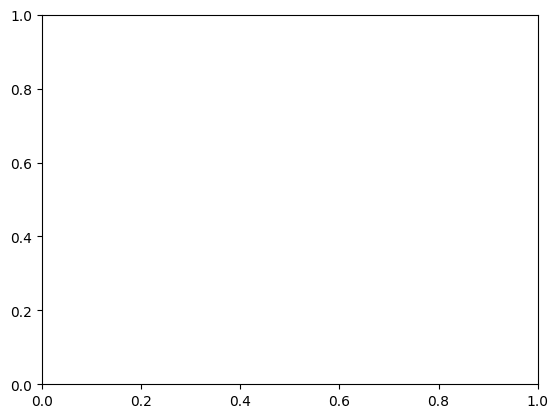

In [5]:
rect = (1100, 3500, 700, 950)
fig, ax = plt.subplots()
ax.imshow(label.cpu())
patch = patches.Rectangle((rect[0], rect[1]), rect[2], rect[3], linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(patch)
plt.show()


In [6]:
# class SubvolumeDataset(data.Dataset):
#     def __init__(self, image_stack, label, pixels):
#         self.image_stack = image_stack
#         self.label = label
#         self.pixels = pixels
#     def __len__(self):
#         return len(self.pixels)
#     def __getitem__(self, index):
#         y, x = self.pixels[index]
#         subvolume = self.image_stack[:, y-BUFFER:y+BUFFER+1, x-BUFFER:x+BUFFER+1].view(1, Z_DIM, BUFFER*2+1, BUFFER*2+1)
#         inklabel = self.label[y, x].view(1)
#         return subvolume, inklabel

# model = nn.Sequential(
#     nn.Conv3d(1, 16, 3, 1, 1), nn.AvgPool3d(kernel_size=3, stride=2, padding=1),
#     nn.Conv3d(16, 32, 3, 1, 1), nn.AvgPool3d(kernel_size=3, stride=2, padding=1),
#     nn.Conv3d(32, 64, 3, 1, 1), nn.AvgPool3d(kernel_size=3, stride=2, padding=1),
#     nn.Flatten(start_dim=1),
#     nn.LazyLinear(512), nn.ReLU(),
#     nn.LazyLinear(1), nn.LogSoftmax()
# ).to(DEVICE)


In [7]:
# class SubvolumeDataset(data.Dataset):
#     def __init__(self, image_stack, label, pixels):
#         self.image_stack = image_stack
#         self.label = label
#         self.pixels = pixels
#     def __len__(self):
#         return len(self.pixels)
#     def __getitem__(self, index):
#         y, x = self.pixels[index]
#         subvolume = self.image_stack[:, y-BUFFER:y+BUFFER+1, x-BUFFER:x+BUFFER+1].view(1, Z_DIM, BUFFER*2+1, BUFFER*2+1)
#         inklabel = self.label[y, x].view(1)
#         return subvolume, inklabel

# model = nn.Sequential(
#         nn.Conv3d(1, 16, 3, 1, 1),
#         nn.MaxPool3d(2, 2),
#         nn.Conv3d(16, 32, 3, 1, 1),
#         nn.MaxPool3d(2, 2),
#         nn.Conv3d(32, 64, 3, 1, 1),
#         nn.MaxPool3d(2, 2),
#         nn.Flatten(start_dim=1),
#         nn.LazyLinear(128), nn.ReLU(),
#         nn.Linear(64*2*2*2, 120),
#         nn.Linear(120, 10),
#         nn.LazyLinear(1), nn.Sigmoid()
# ).to(DEVICE)


In [8]:
class SubvolumeDataset(data.Dataset):
    def __init__(self, image_stack, label, pixels):
        self.image_stack = image_stack
        self.label = label
        self.pixels = pixels
    def __len__(self):
        return len(self.pixels)
    def __getitem__(self, index):
        y, x = self.pixels[index]
        subvolume = self.image_stack[:, y-BUFFER:y+BUFFER+1, x-BUFFER:x+BUFFER+1].view(1, Z_DIM, BUFFER*2+1, BUFFER*2+1)
        inklabel = self.label[y, x].view(1)
        return subvolume, inklabel

model = nn.Sequential(
    nn.Conv3d(1, 16, 3, 1, 1), nn.MaxPool3d(2, 2),
    nn.Conv3d(16, 32, 3, 1, 1), nn.MaxPool3d(2, 2),
    nn.Conv3d(32, 64, 3, 1, 1), nn.MaxPool3d(2, 2),
    nn.Flatten(start_dim=1),
    nn.LazyLinear(128), nn.ReLU(),
    nn.LazyLinear(1), nn.Sigmoid()
).to(DEVICE)


In [9]:
print("Generating pixel lists...")
# Split our dataset into train and val. The pixels inside the rect are the 
# val set, and the pixels outside the rect are the train set.
# Adapted from https://www.kaggle.com/code/jamesdavey/100x-faster-pixel-coordinate-generator-1s-runtime
# Create a Boolean array of the same shape as the bitmask, initially all True
not_border = np.zeros(mask.shape, dtype=bool)
not_border[BUFFER:mask.shape[0]-BUFFER, BUFFER:mask.shape[1]-BUFFER] = True
arr_mask = np.array(mask) * not_border
inside_rect = np.zeros(mask.shape, dtype=bool) * arr_mask
# Sets all indexes with inside_rect array to True
inside_rect[rect[1]:rect[1]+rect[3]+1, rect[0]:rect[0]+rect[2]+1] = True
# Set the pixels within the inside_rect to False
outside_rect = np.ones(mask.shape, dtype=bool) * arr_mask
outside_rect[rect[1]:rect[1]+rect[3]+1, rect[0]:rect[0]+rect[2]+1] = False
pixels_inside_rect = np.argwhere(inside_rect)
pixels_outside_rect = np.argwhere(outside_rect)

print("Training...")
train_dataset = SubvolumeDataset(image_stack, label, pixels_outside_rect)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
criterion = nn.BCELoss() 
# criterion =nn.TripletMarginWithDistanceLoss(distance_function=nn.PairwiseDistance())
# criterion = nn.TripletMarginLoss(margin=1.0, p=2)
# criterion = nn.CosineEmbeddingLoss()
# criterion = nn.L1Loss()
# criterion = nn.KLDivLoss(reduction="batchmean")
# optimizer = optim.Adadelta(model.parameters(), lr=LEARNING_RATE)
# optimizer = optim.RMSprop(model.parameters(), lr=LEARNING_RATE)
optimizer = optim.ASGD(model.parameters(), lr=LEARNING_RATE) # Ink detected
# optimizer = optim.Rprop(model.parameters(), lr=LEARNING_RATE)
# optimizer = optim.Adagrad(model.parameters(), lr=LEARNING_RATE)
# scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.01, max_lr=0.1)
# scheduler = torch.optim.lr_scheduler.ConstantLR(optimizer, factor=0.5, total_iters=4)
scheduler1 = torch.optim.lr_scheduler.ConstantLR(optimizer, factor=0.1, total_iters=2)
scheduler2 = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
scheduler3 = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
lmbda = lambda epoch: 0.95
scheduler4 = torch.optim.lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lmbda)
scheduler5 = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.5, total_iters=4)
scheduler6 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30, T_mult=1)
scheduler = torch.optim.lr_scheduler.ChainedScheduler([scheduler1, scheduler2,scheduler3,scheduler4,scheduler5,scheduler6])
model.train()
# running_loss = 0.0
for i, (subvolumes, inklabels) in tqdm(enumerate(train_loader), total=TRAINING_STEPS):
    if i >= TRAINING_STEPS:
        break
    optimizer.zero_grad()
    outputs = model(subvolumes.to(DEVICE))
    loss = criterion(outputs, inklabels.to(DEVICE))
    loss.backward()
    optimizer.step()
    scheduler.step()
#     running_loss += loss.item()
#     if i % 3000 == 3000-1:
#         print("Loss:", running_loss / 3000)
#         running_loss = 0.0


Generating pixel lists...


NameError: name 'mask' is not defined

In [10]:
eval_dataset = SubvolumeDataset(image_stack, label, pixels_inside_rect)
eval_loader = data.DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)
output = torch.zeros_like(label).float()
model.eval()
with torch.no_grad():
    for i, (subvolumes, _) in enumerate(tqdm(eval_loader)):
        for j, value in enumerate(model(subvolumes.to(DEVICE))):
            output[tuple(pixels_inside_rect[i*BATCH_SIZE+j])] = value

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(output.cpu(), cmap='gray')
ax2.imshow(label.cpu(), cmap='gray')
plt.show()


NameError: name 'image_stack' is not defined

NameError: name 'output' is not defined

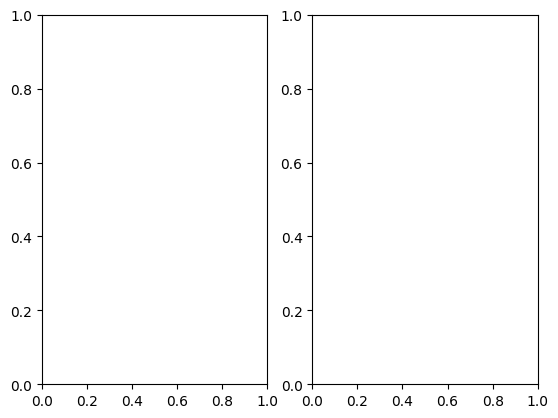

In [11]:
THRESHOLD = 0.4
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(output.gt(THRESHOLD).cpu(), cmap='gray')
ax2.imshow(label.cpu(), cmap='gray')
plt.show()


In [12]:
# Adapted from https://www.kaggle.com/code/stainsby/fast-tested-rle/notebook
# and https://www.kaggle.com/code/kotaiizuka/faster-rle/notebook
def rle(output):
    pixels = np.where(output.flatten().cpu() > THRESHOLD, 1, 0).astype(np.uint8)
    pixels[0] = 0
    pixels[-1] = 0
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 2
    runs[1::2] = runs[1::2] - runs[:-1:2]
    return ' '.join(str(x) for x in runs)
rle_output = rle(output)
# This doesn't make too much sense, but let's just output in the required format
# so notebook works as a submission. :-)
print("Id,Predicted\na," + rle_output + "\nb," + rle_output, file=open('submission.csv', 'w'))


NameError: name 'output' is not defined